### SHAP
###  LIME
### Interpretability Analysis
### Accuracy vs Interpretability Discussion

### Explainable AI Analysis Using SHAP
### 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
# Load the trained LightGBM model
model = joblib.load("final_lightgbm_model.joblib")

print("Final LightGBM model loaded successfully!")

Final LightGBM model loaded successfully!


## 3. Load the Dataset

In [3]:
# Load the engineered dataset
data = pd.read_csv("../Data/engineered_fraud_dataset.csv")

# Display the first five rows
data.head()

,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,...,international_transaction_flag,suspicious_ip_flag,fraud_flag,new_account,high_value_transaction,high_login_attempts,high_velocity,night_transaction,far_distance_transaction,high_device_risk
0,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,...,1,1,0,0,0,0,0,1,0,0
1,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,...,0,1,0,0,0,0,0,0,0,0
2,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,...,0,1,0,0,0,0,0,1,0,0
3,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,...,1,0,0,0,1,0,0,0,0,0
4,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,...,0,0,0,0,0,0,0,0,0,1


## 4. Prepare the Test Data

In [4]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop("fraud_flag", axis=1)
y = data["fraud_flag"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (8000, 25)
Testing Features: (2000, 25)


## 5. Create the SHAP Explainer

In [5]:
print(X_test.dtypes)

transaction_amount                float64
login_attempts                      int64
device_risk_score                 float64
transfer_frequency                  int64
anomaly_score                     float64
account_age_days                    int64
transaction_time_hour               int64
failed_transactions_last_30d        int64
avg_monthly_balance               float64
daily_transaction_count             int64
geo_distance_km                     int64
session_duration_minutes            int64
transaction_velocity_score        float64
payment_channel                    object
authentication_type                object
card_present_flag                   int64
international_transaction_flag      int64
suspicious_ip_flag                  int64
new_account                         int64
high_value_transaction              int64
high_login_attempts                 int64
high_velocity                       int64
night_transaction                   int64
far_distance_transaction          

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop("fraud_flag", axis=1)
y = data["fraud_flag"]

# Apply one-hot encoding (same as model training)
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
X.head()

(10000, 29)


,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,...,high_velocity,night_transaction,far_distance_transaction,high_device_risk,payment_channel_Mobile App,payment_channel_POS Terminal,payment_channel_Web Banking,authentication_type_OTP,authentication_type_Password Only,authentication_type_Two-Factor Authentication
0,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,...,0,1,0,0,False,True,False,True,False,False
1,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,...,0,0,0,0,False,False,True,False,False,False
2,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,...,0,1,0,0,False,False,False,True,False,False
3,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,...,0,0,0,0,True,False,False,True,False,False
4,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,...,0,0,0,1,True,False,False,True,False,False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (8000, 29)
Testing Features: (2000, 29)


In [8]:
print(X_train.columns.tolist())
print(len(X_train.columns))

['transaction_amount', 'login_attempts', 'device_risk_score', 'transfer_frequency', 'anomaly_score', 'account_age_days', 'transaction_time_hour', 'failed_transactions_last_30d', 'avg_monthly_balance', 'daily_transaction_count', 'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score', 'card_present_flag', 'international_transaction_flag', 'suspicious_ip_flag', 'new_account', 'high_value_transaction', 'high_login_attempts', 'high_velocity', 'night_transaction', 'far_distance_transaction', 'high_device_risk', 'payment_channel_Mobile App', 'payment_channel_POS Terminal', 'payment_channel_Web Banking', 'authentication_type_OTP', 'authentication_type_Password Only', 'authentication_type_Two-Factor Authentication']
29


In [9]:
print(X_train.shape)

(8000, 29)


In [10]:
# Create the SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer(X_test)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


## 6. Global Feature Importance

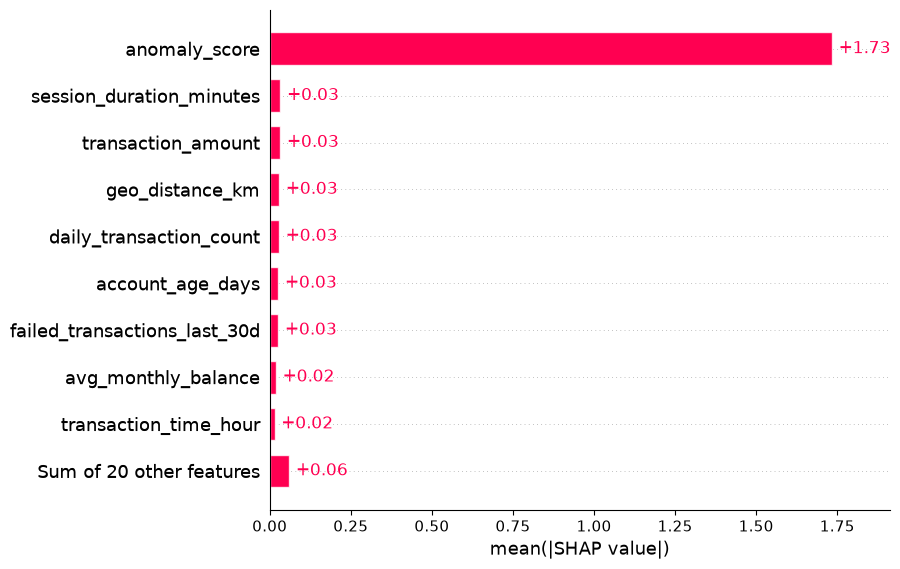

In [11]:
shap.plots.bar(shap_values)

## 8. Local Explanation of an Individual Transaction

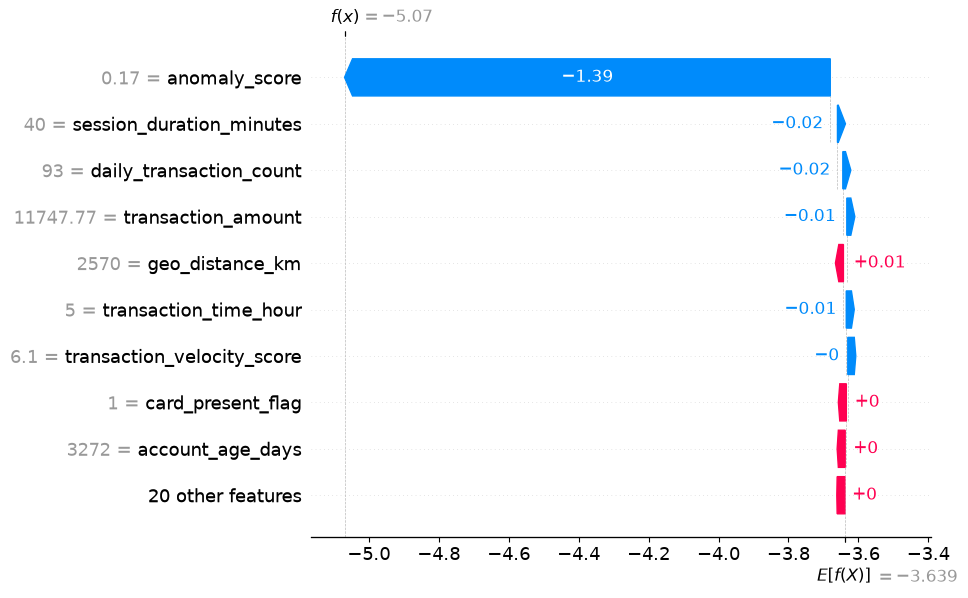

In [12]:
shap.plots.waterfall(shap_values[0])

## 9. SHAP Force Plot

In [13]:
shap.initjs()

shap.plots.force(shap_values[0])

## 10. Interpretation of SHAP Results

In [14]:
import os

# Create Figures folder if it doesn't exist
os.makedirs("../Figures", exist_ok=True)

print("Figures folder is ready.")

Figures folder is ready.


In [15]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("../Figures/shap_summary_plot.png", dpi=300)
plt.close()

In [16]:
import os

print(os.listdir("../Figures"))

['shap_bar_plot.png', 'shap_summary_plot.png', 'shap_waterfall_plot.png']


### BAR PLOT

In [17]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../Figures/shap_bar_plot.png", dpi=300)
plt.close()

In [18]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns
), show=False)

plt.savefig("../Figures/shap_waterfall_plot.png", dpi=300, bbox_inches="tight")
plt.close()

### Interpretation of SHAP Results

The SHAP analysis was performed to improve the interpretability of the optimized LightGBM fraud detection model.

The global feature importance plot revealed that the anomaly score was the most influential feature affecting fraud predictions. This indicates that the model relies heavily on abnormal transaction behaviour when identifying potentially fraudulent transactions. Other important features included session duration, transaction amount, geographical distance, daily transaction count, account age, and failed transactions within the last 30 days.

The SHAP waterfall plot provided a local explanation for an individual transaction. The results showed that the anomaly score contributed most significantly to the final prediction, while the remaining features had relatively smaller effects. This demonstrates that the model can explain why a specific transaction was classified as fraudulent or legitimate.

Similarly, the SHAP force plot visualised how individual feature contributions combined to produce the final prediction. This level of transparency improves user trust and allows financial institutions to understand the reasoning behind model decisions.

Overall, the SHAP analysis demonstrates that the proposed Explainable AI framework not only achieves strong predictive performance but also provides transparent and interpretable explanations for fraud detection decisions, addressing one of the key research gaps identified in this study.

# LIME

In [19]:
import pip

from lime.lime_tabular import LimeTabularExplainer


explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=["Legitimate", "Fraud"],
    mode="classification")

In [20]:
exp = explainer.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=10)

c:\Users\Olami\OneDrive\Documents\DATASCIENCEPROJECT\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [21]:
exp.as_list()

[('anomaly_score <= 0.17', -0.18550090891914237),
 ('daily_transaction_count > 91.00', -0.013866141113784577),
 ('login_attempts <= 3.00', -0.0123406103738351),
 ('248653.46 < avg_monthly_balance <= 370517.51', 0.012144919999713996),
 ('0.00 < international_transaction_flag <= 1.00', 0.011824596583610238),
 ('50.10 < device_risk_score <= 75.50', -0.010320828890316646),
 ('31.00 < session_duration_minutes <= 61.00', -0.009676925156128386),
 ('20.00 < transfer_frequency <= 39.00', 0.009195228041139425),
 ('authentication_type_Password Only <= 0.00', 0.009177430267789454),
 ('transaction_velocity_score <= 24.60', -0.00836397751289111)]

In [22]:
# Find the first fraudulent transaction in the test set
fraud_index = y_test[y_test == 1].index[0]

# Get its position within X_test
fraud_position = X_test.index.get_loc(fraud_index)

print(fraud_position)

11


In [23]:
exp_fraud = explainer.explain_instance(
    X_test.iloc[fraud_position].values,
    model.predict_proba,
    num_features=10)

print(exp_fraud.as_list())

[('anomaly_score > 0.48', 0.5322910478915627), ('avg_monthly_balance <= 122302.98', -0.010110866184697469), ('6.00 < login_attempts <= 9.00', -0.009425766941496478), ('session_duration_minutes > 91.00', 0.007848838246262507), ('24.60 < transaction_velocity_score <= 49.80', 0.007821460591218968), ('new_account <= 0.00', 0.007375342371755657), ('high_velocity <= 0.00', 0.007095094446274828), ('6.00 < failed_transactions_last_30d <= 13.00', 0.006215892279602498), ('authentication_type_Two-Factor Authentication <= 0.00', -0.0062069212829606235), ('transfer_frequency <= 20.00', -0.006006642585659704)]


c:\Users\Olami\OneDrive\Documents\DATASCIENCEPROJECT\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


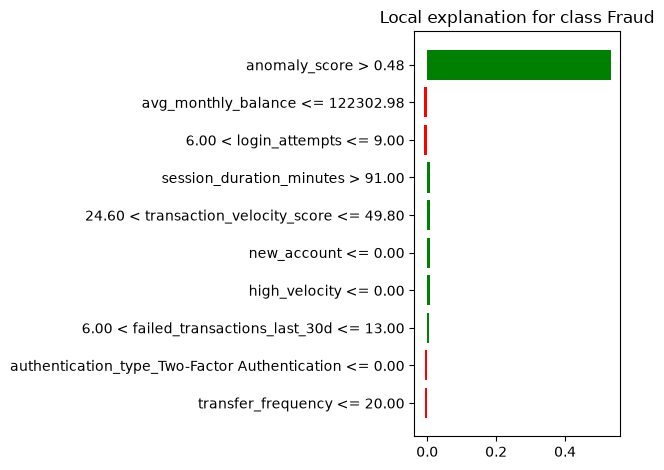

In [24]:
fig = exp_fraud.as_pyplot_figure()

plt.tight_layout()
plt.savefig("lime_fraud_transaction.png", dpi=300, bbox_inches="tight")
plt.show()